In [1]:
import sys
sys.path.insert(0, "..")

In [2]:
import torch
import matplotlib.pyplot as plt

from normalizing_flows.model import GlowModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
def display(images, title=None):
    """Display a row of images. Expects (N, C, H, W) tensor in [0, 1]."""
    n = images.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(images[i].permute(1, 2, 0).numpy())
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def load_model(checkpoint_path):
    model = GlowModel(
        in_channels=3,
        num_levels=3,
        num_steps=32,
        hidden_channels=512,
    )
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    print(f"Loaded checkpoint: {checkpoint_path}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    return model

In [4]:
@torch.no_grad()
def inference(checkpoint_path, num_samples=4, temperature=0.7):
    model = load_model(checkpoint_path)
    samples = model.sample(num_samples, device=device, temperature=temperature)
    # Rescale from [-0.5, 0.5] to [0, 1]
    samples = (samples + 0.5).clamp(0, 1).cpu()
    print(f"Samples shape: {samples.shape}")
    display(samples, title=f"temperature={temperature}")

/home/CORP/shuai.lou/miniconda3/envs/aigc-examples/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Loaded checkpoint: model_epoch_90.pth
Parameters: 44,250,768
Samples shape: torch.Size([4, 3, 64, 64])


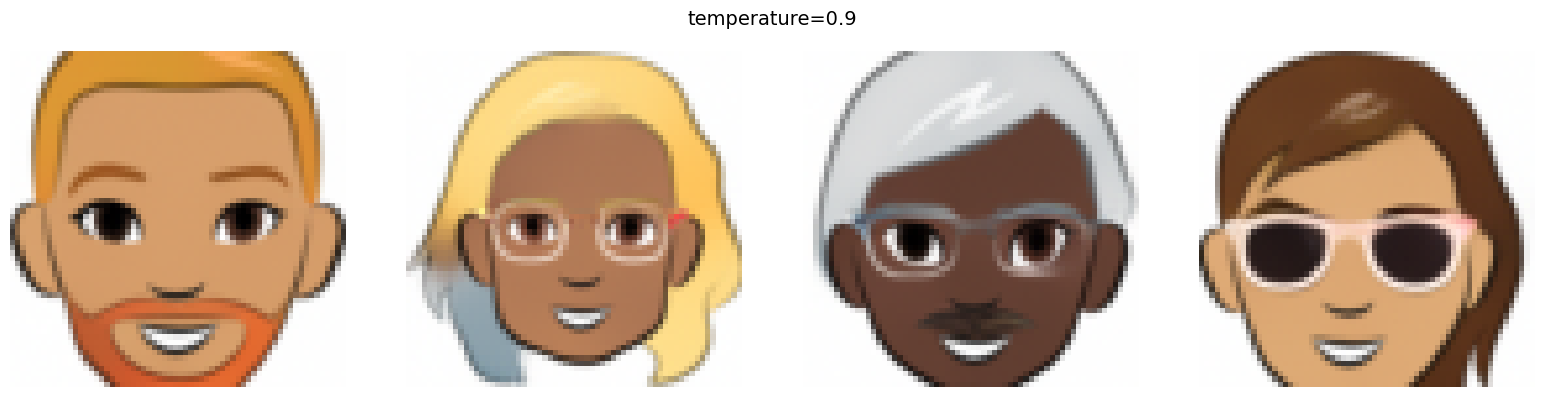

In [5]:
inference("model_epoch_90.pth", temperature=0.9)

Loaded checkpoint: model_epoch_90.pth
Parameters: 44,250,768


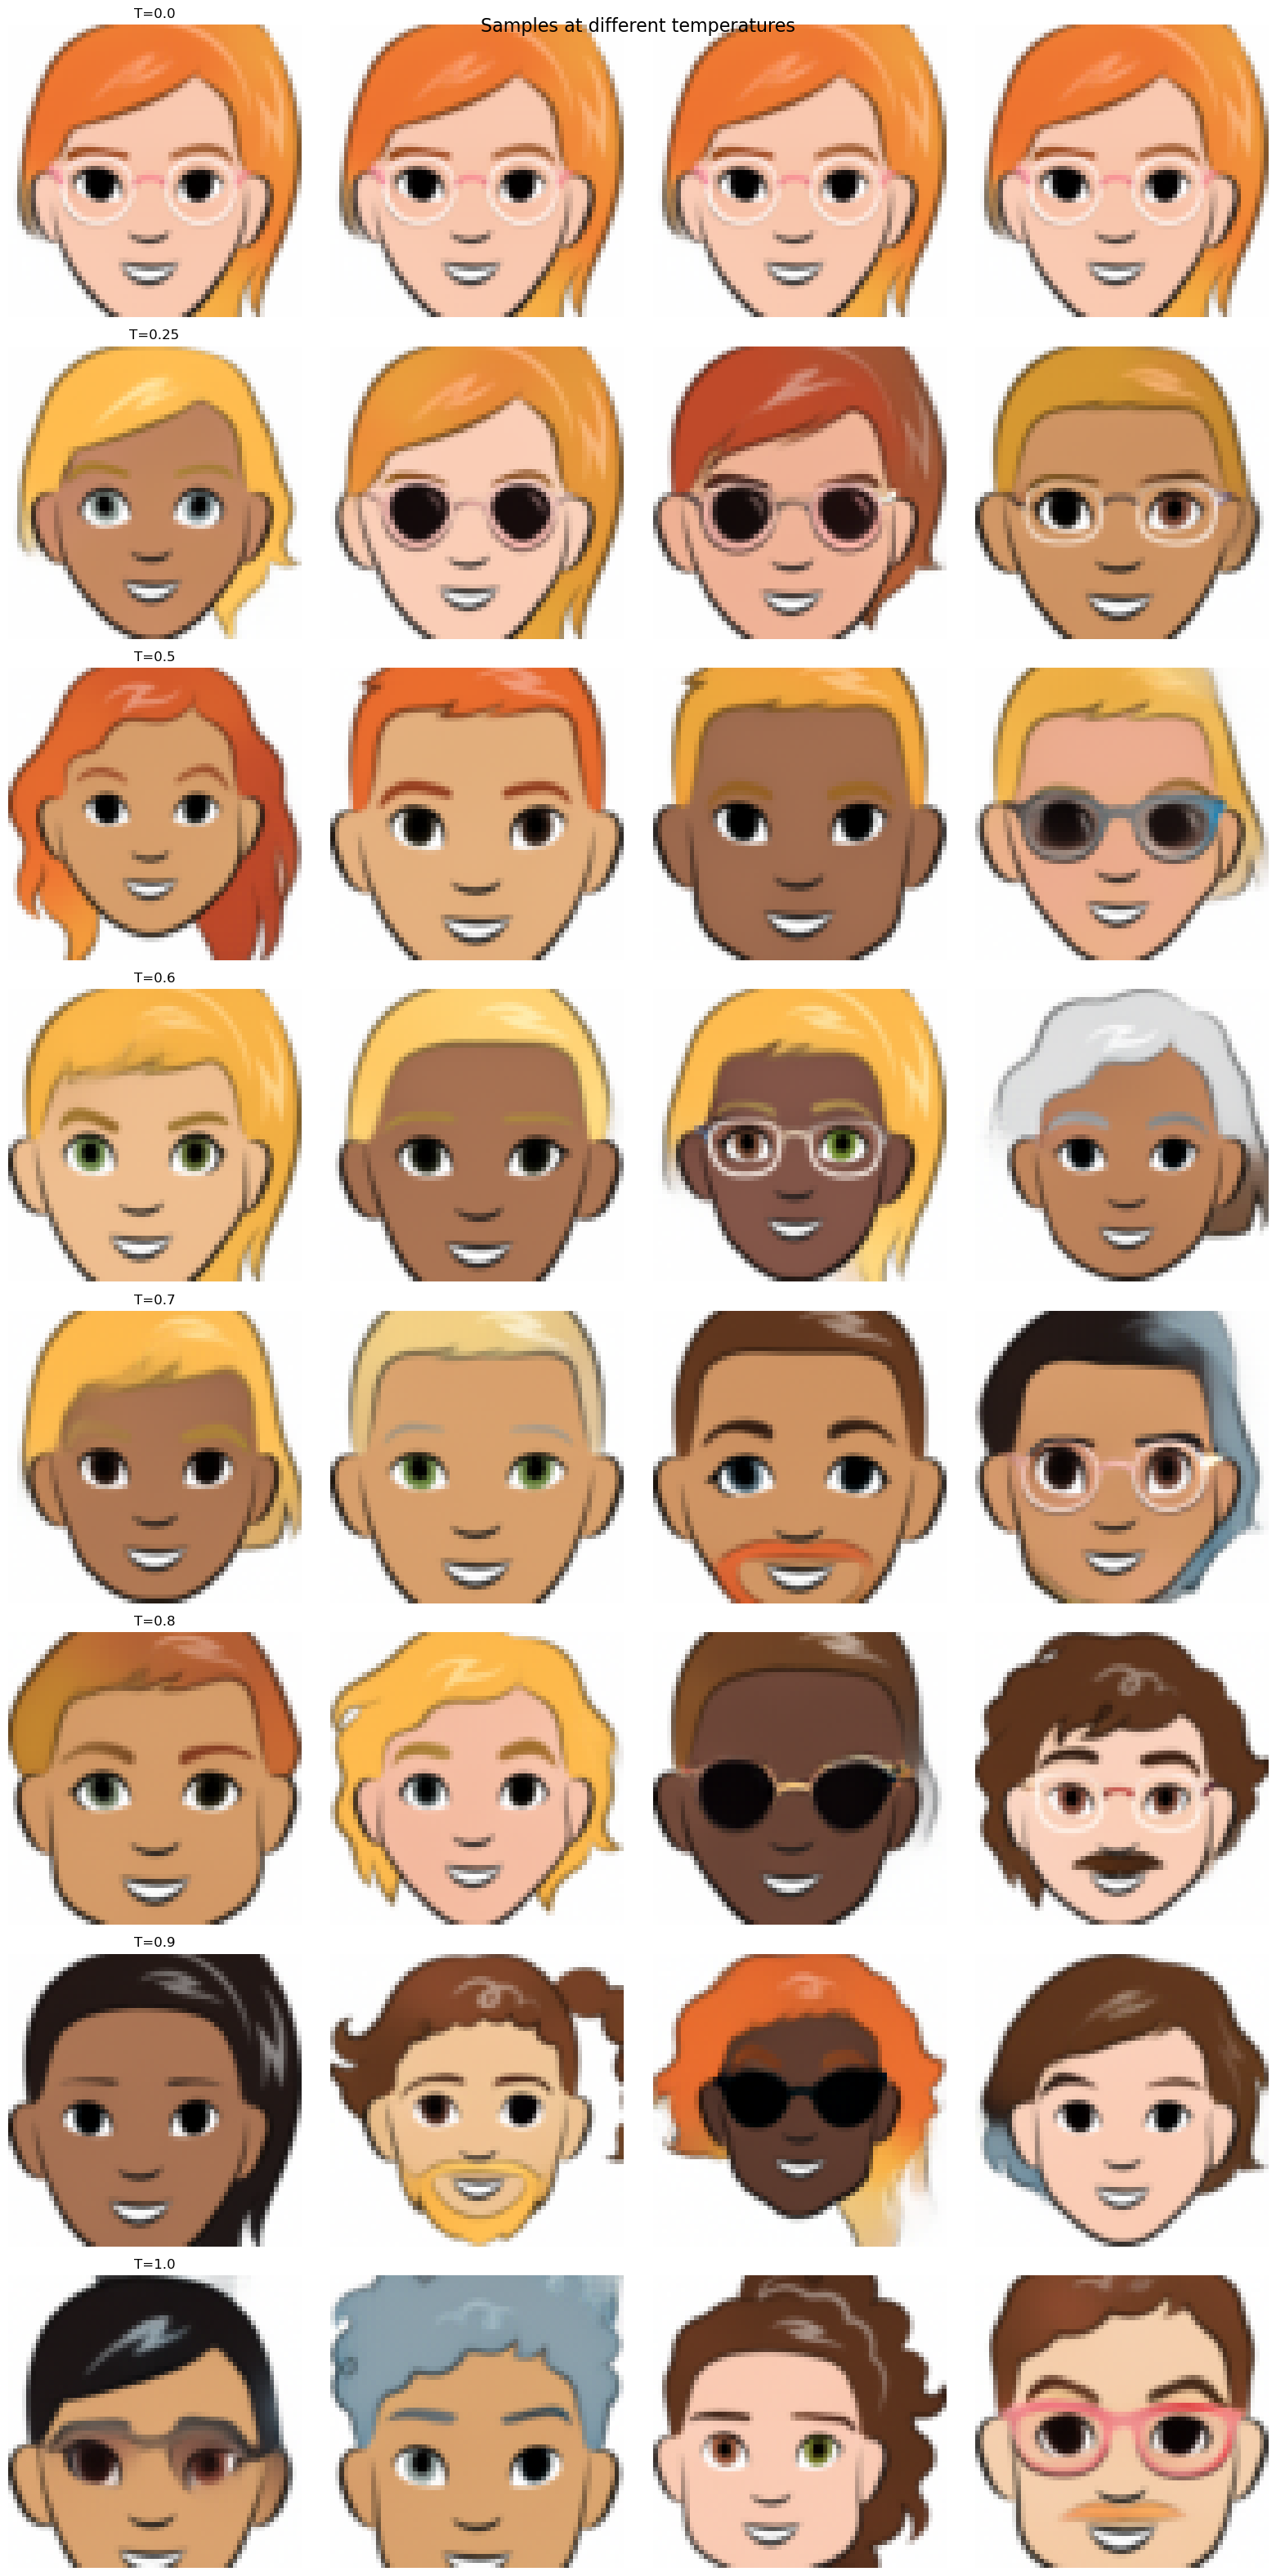

In [6]:
@torch.no_grad()
def compare_temperatures(checkpoint_path, num_samples=4):
    """Sample at multiple temperatures, matching the TF reference visualization."""
    model = load_model(checkpoint_path)
    temperatures = [0.0, 0.25, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    fig, axes = plt.subplots(len(temperatures), num_samples,
                             figsize=(4 * num_samples, 4 * len(temperatures)))
    for row, t in enumerate(temperatures):
        samples = model.sample(num_samples, device=device, temperature=t)
        samples = (samples + 0.5).clamp(0, 1).cpu()
        for col in range(num_samples):
            axes[row, col].imshow(samples[col].permute(1, 2, 0).numpy())
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_title(f"T={t}", fontsize=12)
    plt.suptitle("Samples at different temperatures", fontsize=16)
    plt.tight_layout()
    plt.show()


compare_temperatures("model_epoch_90.pth", num_samples=4)